In [2]:
# Making Pooled Distribution
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:
def parse_year(year_val):
    """Convert year string like '2022S', '2022A', '2022W' to numeric year."""
    if isinstance(year_val, str):
        if year_val.endswith("S"):
            return int(year_val[:-1]) - 0.5
        elif year_val.endswith(("A", "W")):
            return int(year_val[:-1])
        else:
            return int(year_val)  # just in case it's string but plain year
    return int(year_val)  # if it's already an int
    

# Set up paths
folder_path = "EU_dataset"
file_title = "Cleaned_Parlemeter_Data-LeftRight"
file_name = file_title + ".xlsx"
survey_file = os.path.join(folder_path, file_name)
sheets = pd.ExcelFile(survey_file).sheet_names[1:]  # Skip 'RowHeaders'
survey_data = []

for sheet in sheets:
    country = sheet.split("-")[0]  # Extract country code (e.g., "BE")
    df_sheet = pd.read_excel(survey_file, sheet_name=sheet, header=None)
    
    # Years are in the first row
    years = df_sheet.iloc[0, :].tolist()
    
    # Extract counts for positions 1-10 (skip % rows and DK/Refusal)
    counts_matrix = []
    for i in range(10):  # Positions 1-10
        row_index = 2 + 2 * i  # Count rows are at indices 1,3,5,...,19
        counts_matrix.append(df_sheet.iloc[row_index, :].tolist())
    # print(counts_matrix[0][1])
    # Process each year
    for j, year in enumerate(years):
        year_num = parse_year(year)  # use parsed numeric year
        counts = [float(counts_matrix[i][j]) for i in range(10)]
        total_valid = sum(counts)
        distribution = [c / total_valid for c in counts]
        pooled_counts = counts[:4] + [counts[4] + counts[5]] + counts[6:]
        pooled_distribution = [c / total_valid for c in pooled_counts]
        pooled_distribution_counts = [c for c in pooled_counts]
    
        survey_data.append({
            "country": country,
            "year": year_num,
            "binned_distribution": distribution,
            "binned_distribution_5_6clubbed": pooled_distribution,
            "binned_counts_5_6clubbed": pooled_distribution_counts,
            "total_respondents": total_valid
        })
survey_df = pd.DataFrame(survey_data)

In [4]:
survey_df

,country,year,binned_distribution,binned_distribution_5_6clubbed,binned_counts_5_6clubbed,total_respondents
0,BE,2007,"[0.03948772678762007, 0.030949839914621132, 0....","[0.03948772678762007, 0.030949839914621132, 0....","[37.0, 29.0, 111.0, 119.0, 464.0, 80.0, 60.0, ...",937.0
1,BE,2010,"[0.04880694143167028, 0.04121475054229935, 0.0...","[0.04880694143167028, 0.04121475054229935, 0.0...","[45.0, 38.0, 92.0, 124.0, 421.0, 110.0, 54.0, ...",922.0
2,BE,2012,"[0.03479125248508946, 0.040755467196819085, 0....","[0.03479125248508946, 0.040755467196819085, 0....","[35.0, 41.0, 91.0, 137.0, 421.0, 161.0, 95.0, ...",1006.0
3,BE,2014,"[0.06989247311827956, 0.02795698924731183, 0.1...","[0.06989247311827956, 0.02795698924731183, 0.1...","[65.0, 26.0, 106.0, 100.0, 406.0, 131.0, 62.0,...",930.0
4,BE,2015,"[0.035343035343035345, 0.033264033264033266, 0...","[0.035343035343035345, 0.033264033264033266, 0...","[34.0, 32.0, 105.0, 131.0, 430.0, 126.0, 53.0,...",962.0
...,...,...,...,...,...,...
460,HR,2022,"[0.057385759829968117, 0.026567481402763018, 0...","[0.057385759829968117, 0.026567481402763018, 0...","[54.0, 25.0, 49.0, 81.0, 423.0, 94.0, 94.0, 41...",941.0
461,HR,2023,"[0.06465067778936393, 0.026068821689259645, 0....","[0.06465067778936393, 0.026068821689259645, 0....","[62.0, 25.0, 72.0, 95.0, 443.0, 82.0, 52.0, 46...",959.0
462,HR,2024,"[0.05834186284544524, 0.02354145342886387, 0.0...","[0.05834186284544524, 0.02354145342886387, 0.0...","[57.0, 23.0, 65.0, 119.0, 395.0, 96.0, 79.0, 2...",977.0
463,HR,2024,"[0.06951871657754011, 0.017112299465240642, 0....","[0.06951871657754011, 0.017112299465240642, 0....","[65.0, 16.0, 46.0, 113.0, 356.0, 99.0, 104.0, ...",935.0


In [5]:
# Summing

binned_counts = survey_df['binned_counts_5_6clubbed']
# print(a)
# print(type(a))

binned_counts = binned_counts.apply(np.array)
# print(len(b))

summed_bin_counts = binned_counts.sum()
# print(c)
# print(type(c))

total_valids = survey_df['total_respondents']

summed_total_valids = total_valids.sum()


In [6]:
print(summed_bin_counts)
print(summed_total_valids)

[ 19349.  15819.  39157.  43594. 165892.  45346.  33032.  10379.  18737.]
391305.0


In [7]:
pooled_distribution = summed_bin_counts/summed_total_valids

print(pooled_distribution)

print(f"Our pooled distribution is as close to summing to 1 as {np.sum(pooled_distribution)}")

[0.04944736 0.04042627 0.10006772 0.1114067  0.42394552 0.11588403
 0.08441497 0.02652407 0.04788336]
Our pooled distribution is as close to summing to 1 as 0.9999999999999999


In [21]:
binwise_scale_points = [[1], [2], [3], [4], [5, 6], [7], [8], [9], [10]]
binwise_scale_points_labels = []
for i in (binwise_scale_points):
    binwise_scale_points_labels.append(str(i))
binwise_scale_points_labels = np.array(binwise_scale_points_labels)
print(binwise_scale_points_labels)                     

['[1]' '[2]' '[3]' '[4]' '[5, 6]' '[7]' '[8]' '[9]' '[10]']


<BarContainer object of 9 artists>

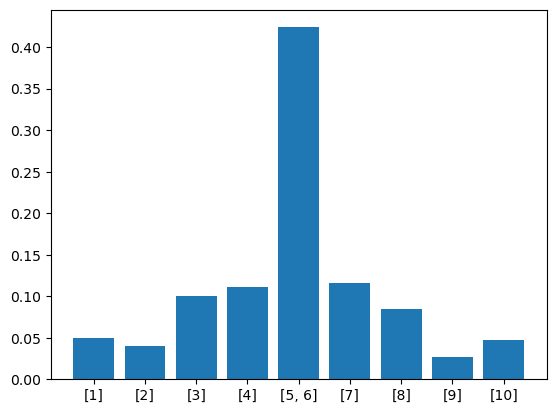

In [15]:
plt.bar(binwise_scale_points_labels , pooled_distribution)

In [22]:

# Convert inner lists to comma-separated strings inside quotes if they have multiple items
labels_list = []
for item in binwise_scale_points:
    if len(item) > 1:
        # Joins numbers with a comma and space, wrapped in double quotes
        labels_list.append(f'"{", ".join(map(str, item))}"')
    else:
        labels_list.append(str(item[0]))

# Convert your processed list into a 1D NumPy array of strings
binwise_scale_points_labels = np.array(labels_list)


combined_array = np.vstack((binwise_scale_points_labels, pooled_distribution))
np.savetxt('EU_Dataset/pooled_distribution.csv', combined_array, delimiter=',', fmt='%s')